# DBSCAN-Based Detection of Environmental Anomalies in Ahmedabad (2023–2025)

This project applies the DBSCAN clustering algorithm to identify unusual air pollution events (anomalies) using CPCB monitoring data collected from multiple stations in Ahmedabad.

The objective is to separate normal pollution behaviour from irregular spikes that may indicate environmental anomalies.

## Objective

The main goal of this project is to detect abnormal pollution events using an unsupervised machine learning technique.

We aim to:
- Cluster normal air quality patterns across stations
- Detect rare pollution spikes as anomalies
- Study monthly and station-wise anomaly trends

## Dataset Description

**Source:** CPCB CAAQMS Portal  
**Location:** Ahmedabad, Gujarat  
**Time Period:** 2023–2025  
**Number of Stations:** 9

Pollutants included:
- PM2.5, PM10, NO₂, SO₂, CO, O₃

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from kneed import KneeLocator

## Loading the Dataset

The dataset is imported using Pandas.  
It contains air quality measurements from CPCB monitoring stations in Ahmedabad for the years 2023–2025.

In [4]:
df = pd.read_csv("final_data.csv")
df.shape

(236736, 9)

In [5]:
df.head()

,From Date,To Date,Station_Name,PM2.5,PM10,NO2,SO2,CO,Ozone
0,01-01-2023 00:00,01-01-2023 01:00,Chandkheda,NaN,NaN,NaN,NaN,NaN,NaN
1,01-01-2023 01:00,01-01-2023 02:00,Chandkheda,NaN,NaN,NaN,NaN,NaN,NaN
2,01-01-2023 02:00,01-01-2023 03:00,Chandkheda,NaN,NaN,NaN,NaN,NaN,NaN
3,01-01-2023 03:00,01-01-2023 04:00,Chandkheda,NaN,NaN,NaN,NaN,NaN,NaN
4,01-01-2023 04:00,01-01-2023 05:00,Chandkheda,NaN,NaN,NaN,NaN,NaN,NaN


# Data Preprocessing

Real-world pollution datasets often contain missing values and irregular measurements.  
Therefore, preprocessing is required before applying DBSCAN.

In [6]:
df = df.rename(columns={"From Date": "Timestamp","To Date": "To_Timestamp"})
df["Timestamp"] = pd.to_datetime(df["Timestamp"], dayfirst=True, errors="coerce")
df = df.dropna(subset=["Timestamp"])
pollutants = ["PM2.5", "PM10", "NO2", "SO2", "CO", "Ozone"]
# Remove rows where all pollutants are NaN
df = df.dropna(subset=pollutants, how="all")
# Sort + interpolate per station
df = df.sort_values(["Station_Name", "Timestamp"])
df = df.set_index("Timestamp")
df[pollutants] = (df.groupby("Station_Name", group_keys=False)[pollutants].apply(lambda x: x.interpolate(method="time")))
df_model = df.dropna(subset=pollutants).reset_index()
print("Final rows:", df_model.shape[0])
print("Stations:", df_model["Station_Name"].nunique())

Final rows: 208572
Stations: 9


In [7]:
# Sample scaling
sample = df_model.sample(n=30000, random_state=42)
X_sample = sample[pollutants]
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_sample)

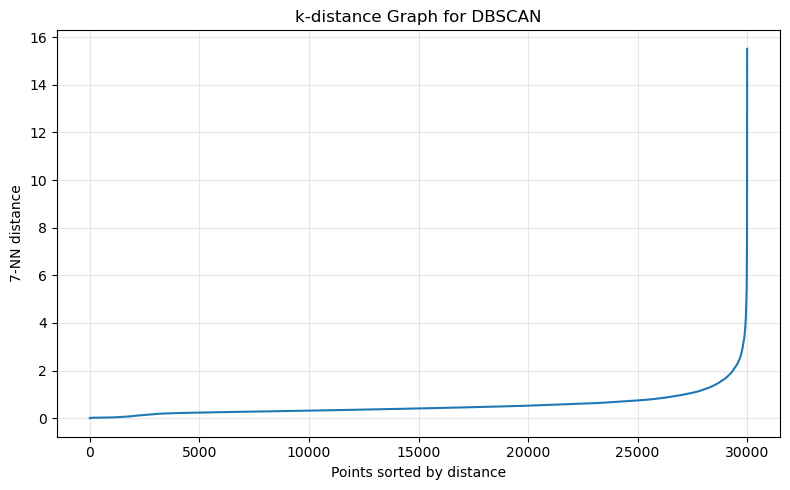

In [8]:
# FIND EPS using elbow point detection
from sklearn.neighbors import NearestNeighbors
import numpy as np
X = X_scaled
k = 7
nbrs = NearestNeighbors(n_neighbors=k).fit(X)
distances, _ = nbrs.kneighbors(X)
k_distances = np.sort(distances[:, -1])
plt.figure(figsize=(8,5))
plt.plot(k_distances)
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{k}-NN distance")
plt.title("k-distance Graph for DBSCAN")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
from kneed import KneeLocator
k = 7
nbrs = NearestNeighbors(n_neighbors=k).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])
# Find knee point
knee = KneeLocator(range(len(k_distances)),k_distances,curve="convex",direction="increasing")
eps = k_distances[knee.knee]
print(" Selected eps value:", round(eps, 5))

 Selected eps value: 2.52761


In [10]:
# STATION-WISE DBSCAN

df_model["Cluster_Label"] = np.nan
df_model["Is_Anomaly"] = False

min_samples = 7

for station, g in df_model.groupby("Station_Name"):
    if len(g) < 100:
        continue

    idx = g.index
    X = g[pollutants]

    X_scaled = RobustScaler().fit_transform(X)

    db = DBSCAN(eps=eps, min_samples=min_samples)
    labels = db.fit_predict(X_scaled)

    df_model.loc[idx, "Cluster_Label"] = labels
    df_model.loc[idx, "Is_Anomaly"] = (labels == -1)

print("Anomaly counts:")
print(df_model["Is_Anomaly"].value_counts())


Anomaly counts:
Is_Anomaly
False    207871
True        701
Name: count, dtype: int64


In [11]:
# ADD STATION COORDINATES
station_coords = {
    "Chandkheda": (23.1100, 72.5700),
    "Gyaspur": (22.9800, 72.6100),
    "Maninagar": (22.9980, 72.6010),
    "Raikhad": (23.0225, 72.5850),
    "Rakhial": (23.0030, 72.6170),
    "SAC ISRO Bopal": (23.0330, 72.4670),
    "SAC ISRO Satellite": (23.0390, 72.4780),
    "SVPI Airport Hansol": (23.0730, 72.6260),
    "Sardar Vallabhbhai Patel Stadium": (23.0425, 72.5650)}

df_model["Latitude"] = df_model["Station_Name"].map(lambda x: station_coords[x][0])
df_model["Longitude"] = df_model["Station_Name"].map(lambda x: station_coords[x][1])

In [12]:
# 7. RENAME POLLUTANTS WITH UNITS & SUBSCRIPTS
df_model = df_model.rename(columns={
    "PM2.5": "PM2.5 (µg/m³)",
    "PM10": "PM10 (µg/m³)",
    "NO2": "NO₂ (µg/m³)",
    "SO2": "SO₂ (µg/m³)",
    "CO": "CO (mg/m³)",
    "Ozone": "O₃ (µg/m³)"})


In [13]:
# 6. SAVE TABLEAU FILE

tableau_cols = ["Timestamp","Station_Name","Latitude","Longitude",
                "PM2.5 (µg/m³)","PM10 (µg/m³)","NO₂ (µg/m³)","SO₂ (µg/m³)","CO (mg/m³)","O₃ (µg/m³)","Cluster_Label","Is_Anomaly"]

df_model[tableau_cols].to_csv("ahd_dbscan.csv", index=False)

print("\n✅ Tableau file saved as: ahd_dbscan_.csv")


✅ Tableau file saved as: ahd_dbscan_.csv


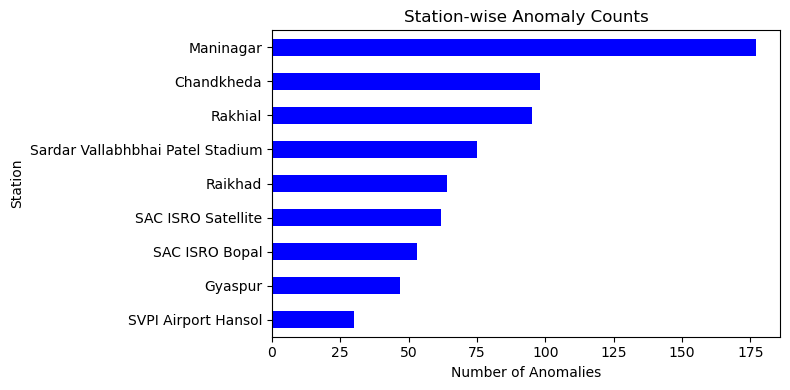

In [14]:
anomaly_counts = (df_model[df_model["Is_Anomaly"] == True].groupby("Station_Name").size().sort_values())
plt.figure(figsize=(8,4))
anomaly_counts.plot(kind="barh", color="blue")
plt.title("Station-wise Anomaly Counts")
plt.xlabel("Number of Anomalies")
plt.ylabel("Station")
plt.tight_layout()
plt.show()

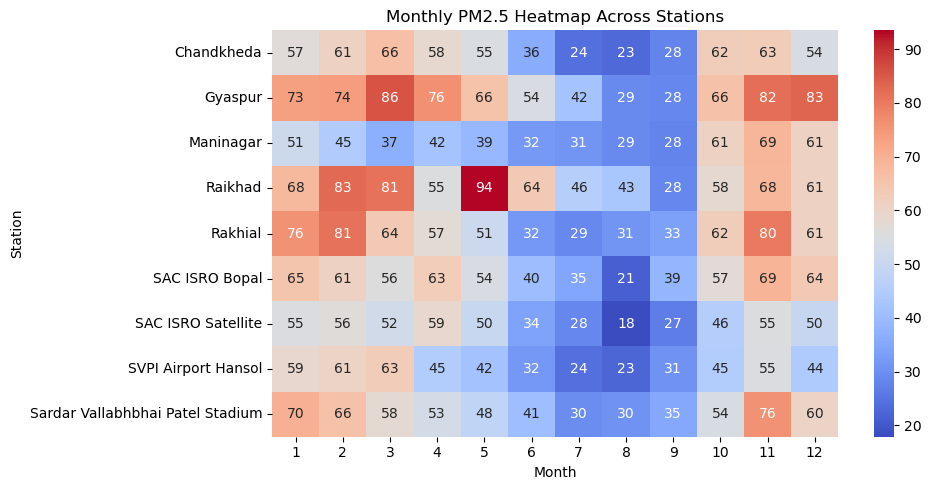

In [15]:
import seaborn as sns
pivot = df_model.pivot_table(values="PM2.5 (µg/m³)",index="Station_Name",columns=df_model["Timestamp"].dt.month, aggfunc="mean")
plt.figure(figsize=(10,5))
sns.heatmap(pivot, cmap="coolwarm",annot=True)
plt.title("Monthly PM2.5 Heatmap Across Stations")
plt.xlabel("Month")
plt.ylabel("Station")
plt.tight_layout()
plt.show()

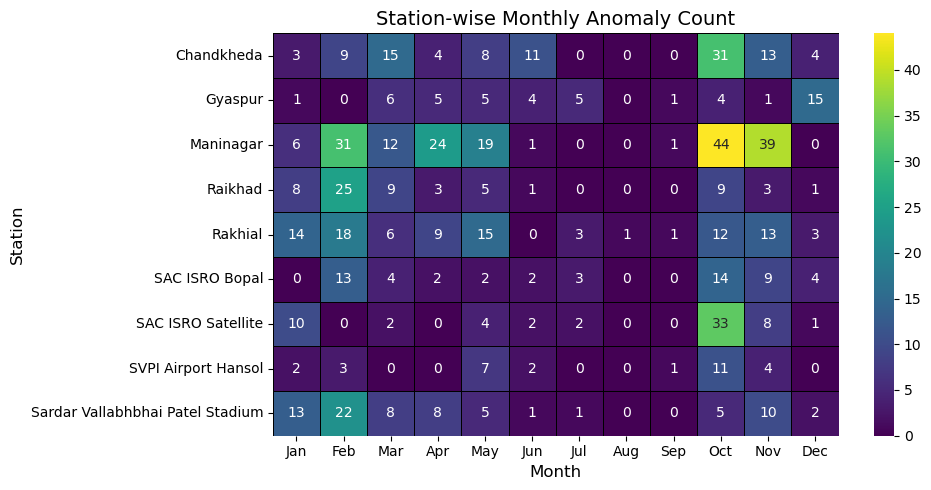

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# 1. Ensure Timestamp is datetime
df_model["Timestamp"] = pd.to_datetime(df_model["Timestamp"])
# 2. Create Month column (Jan, Feb, Mar...)
df_model["Month"] = df_model["Timestamp"].dt.strftime("%b")
# 3. Set correct month order
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
df_model["Month"] = pd.Categorical(df_model["Month"],categories=month_order,ordered=True)
# 4. Convert anomaly boolean to numeric
df_model["Anomaly_Flag"] = df_model["Is_Anomaly"].astype(int)
# 5. Count anomalies per station per month
monthly_anomaly = df_model.groupby(["Station_Name", "Month"],observed=False)["Anomaly_Flag"].sum().reset_index()
# 6. Create pivot table
pivot = monthly_anomaly.pivot(index="Station_Name",columns="Month",values="Anomaly_Flag")
# 7. Plot heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(pivot,annot=True,fmt=".0f",cmap="viridis",linewidths=0.5,linecolor='black')
# 8. Labels and title
plt.title("Station-wise Monthly Anomaly Count", fontsize=14)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Station", fontsize=12)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

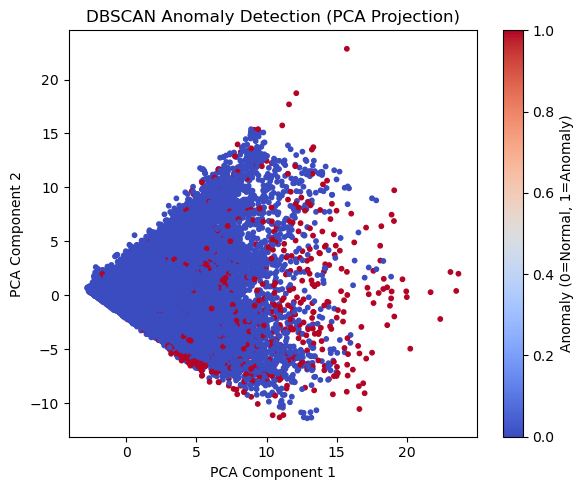

In [30]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler
features = ["PM2.5 (µg/m³)", "PM10 (µg/m³)","NO₂ (µg/m³)", "SO₂ (µg/m³)","CO (mg/m³)", "O₃ (µg/m³)"]
X = df_model[features]
X_scaled = RobustScaler().fit_transform(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1],c=df_model["Is_Anomaly"],cmap="coolwarm",s=10)
plt.title("DBSCAN Anomaly Detection (PCA Projection)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label="Anomaly (0=Normal, 1=Anomaly)")
plt.tight_layout()
plt.show()


In [31]:
df_model   # final dataframe after DBSCAN
pollutants = ["PM2.5 (µg/m³)", "PM10 (µg/m³)", "NO₂ (µg/m³)", "SO₂ (µg/m³)", "CO (mg/m³)", "O₃ (µg/m³)"]


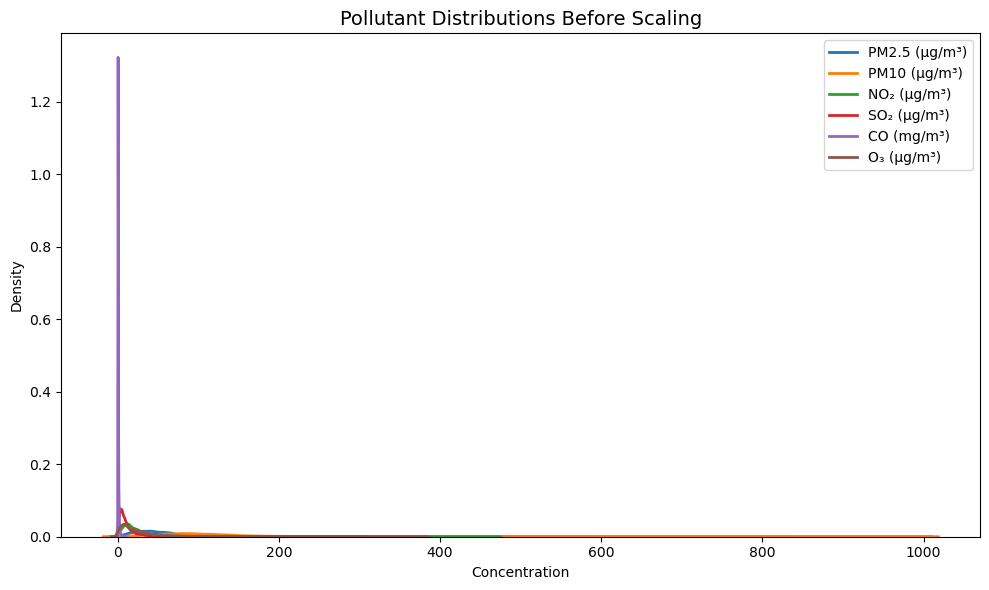

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
for col in pollutants:
    sns.kdeplot(df_model[col], label=col, linewidth=2)
plt.title("Pollutant Distributions Before Scaling", fontsize=14)
plt.xlabel("Concentration")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

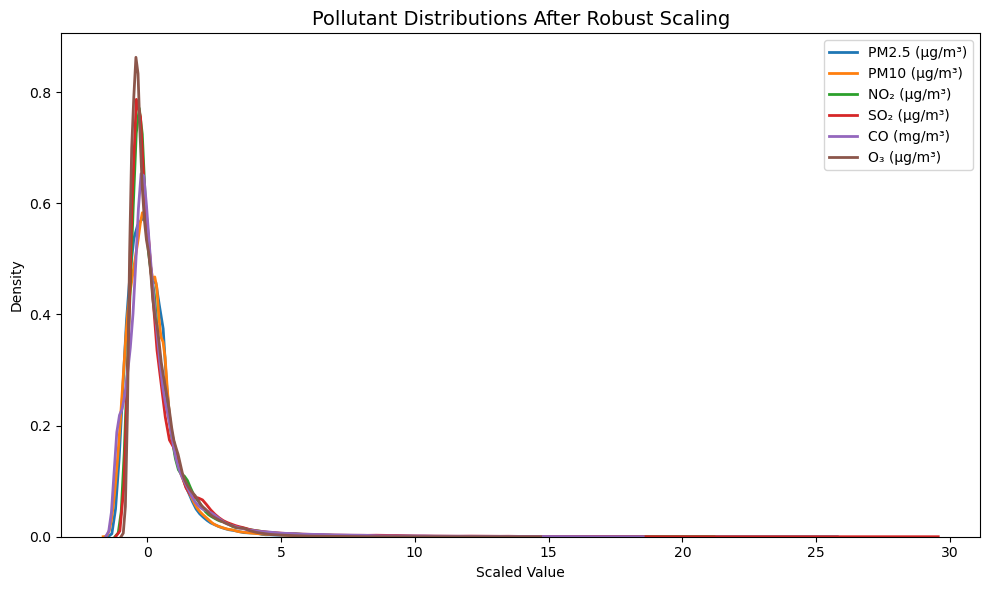

In [33]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
scaled = scaler.fit_transform(df_model[pollutants])
scaled_df = pd.DataFrame(scaled, columns=pollutants)

plt.figure(figsize=(10,6))

for col in pollutants:
    sns.kdeplot(scaled_df[col], label=col, linewidth=2)

plt.title("Pollutant Distributions After Robust Scaling", fontsize=14)
plt.xlabel("Scaled Value")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

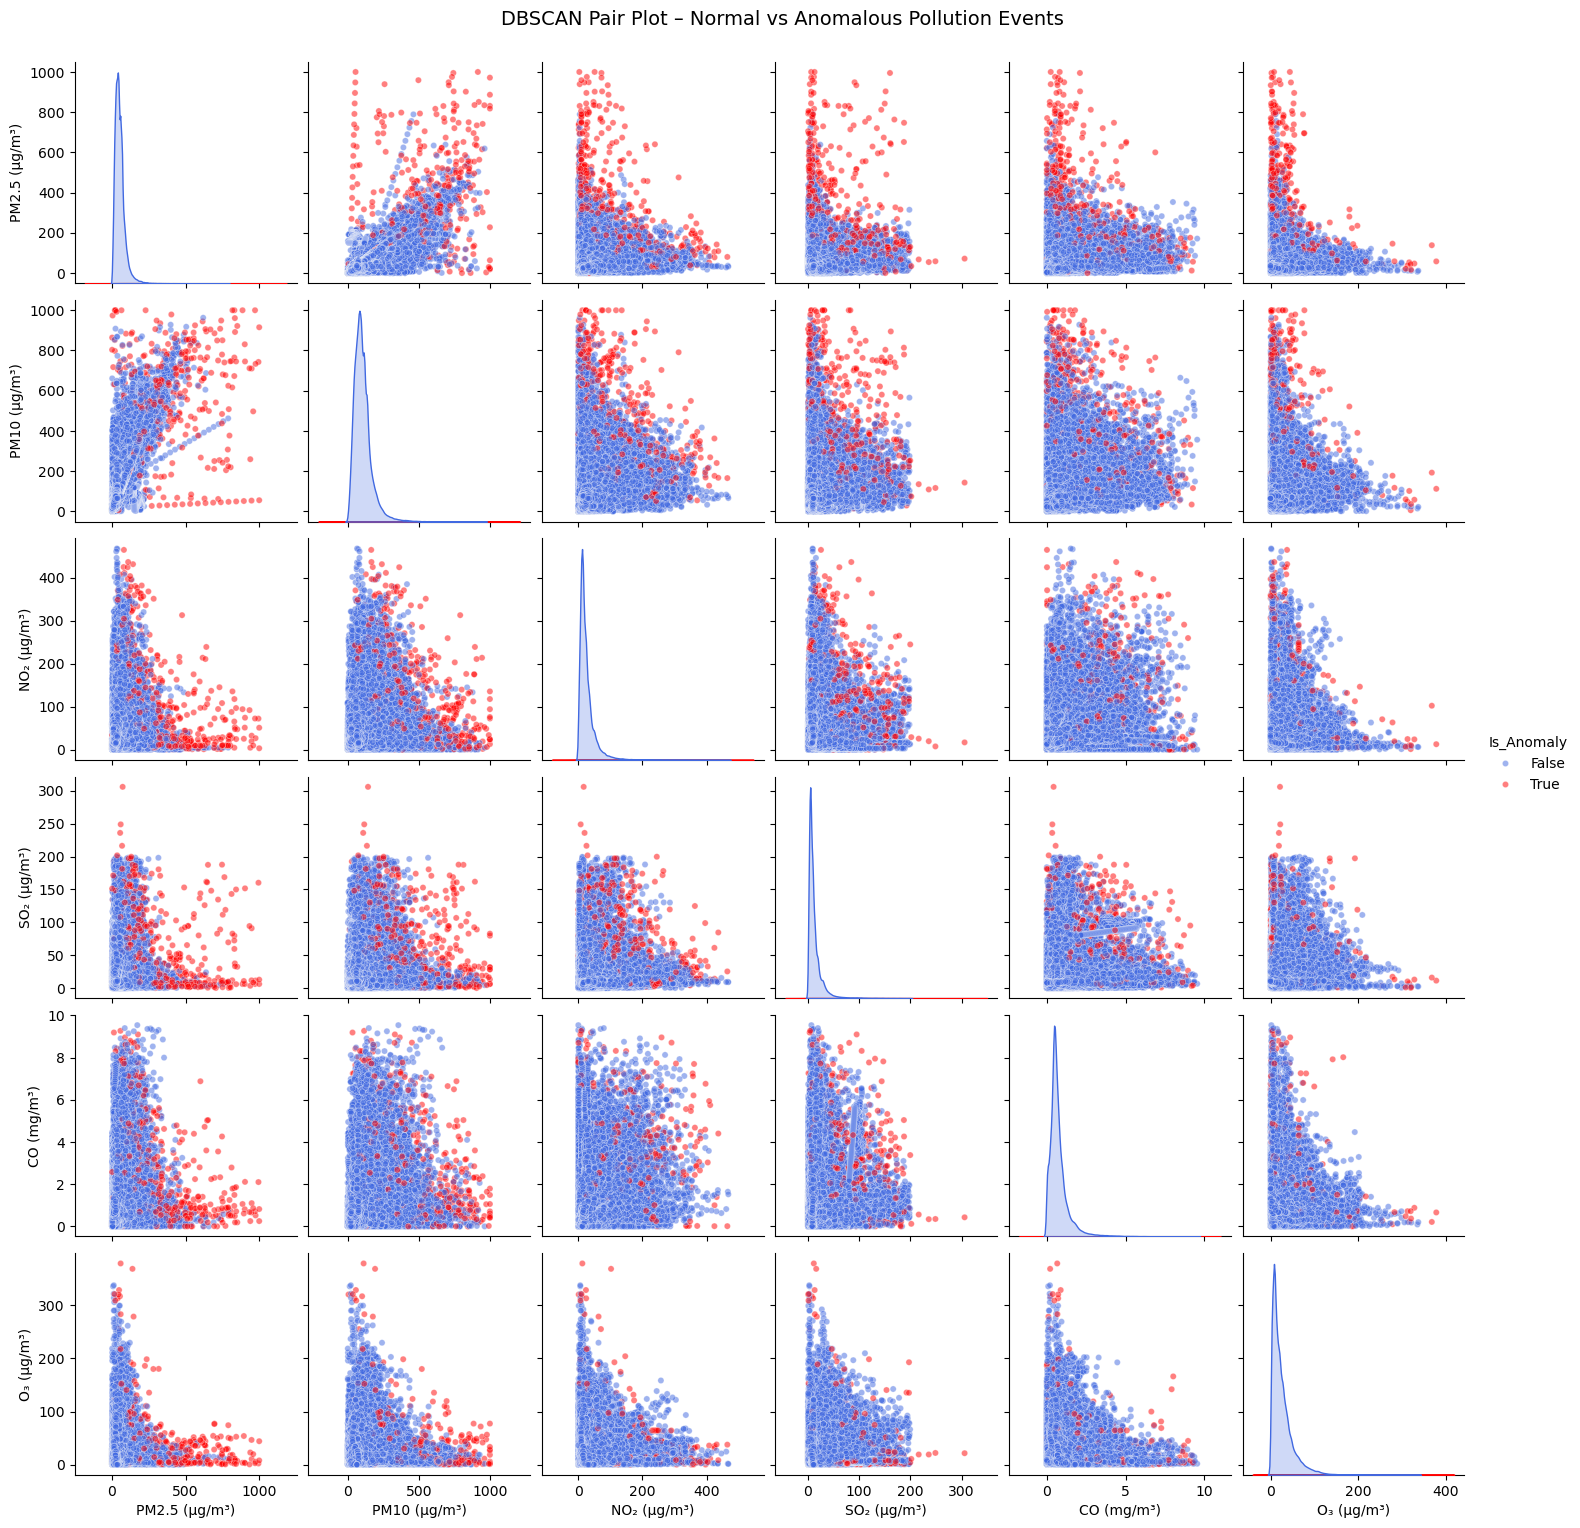

In [18]:
sns.pairplot(df_model,
    vars=pollutants,hue="Is_Anomaly",palette={False: "royalblue", True: "red"},plot_kws={"alpha": 0.5, "s": 20},diag_kind="kde")
plt.suptitle("DBSCAN Pair Plot – Normal vs Anomalous Pollution Events",
             y=1.02, fontsize=14)
plt.show()

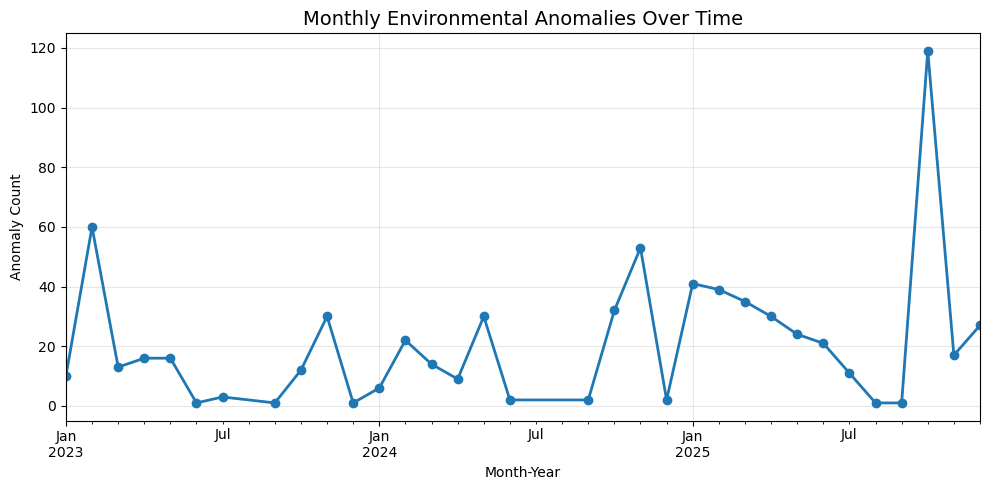

In [19]:
df_model["Month_Year"] = df_model["Timestamp"].dt.to_period("M")

monthly_anomalies = (df_model[df_model["Is_Anomaly"]].groupby("Month_Year").size())
plt.figure(figsize=(10,5))
monthly_anomalies.plot(marker="o", linewidth=2)
plt.title("Monthly Environmental Anomalies Over Time", fontsize=14)
plt.xlabel("Month-Year")
plt.ylabel("Anomaly Count")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

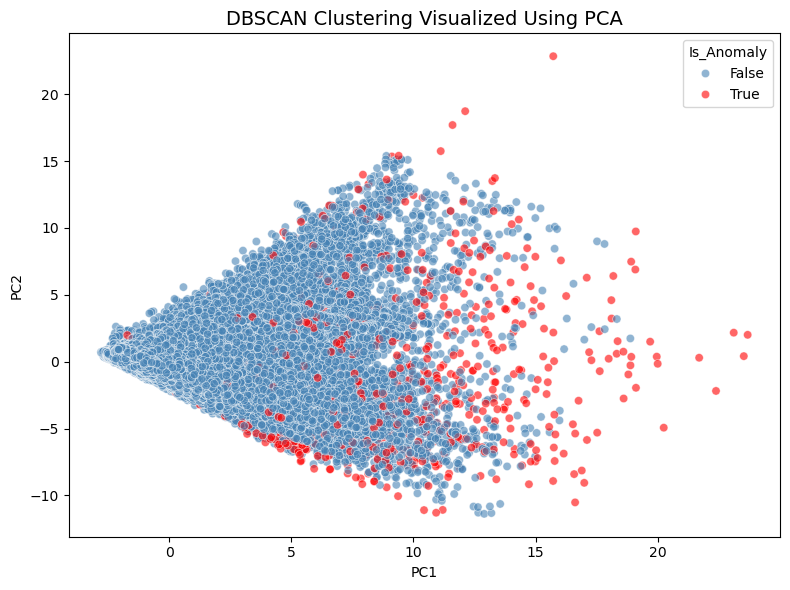

In [20]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(scaled_df)
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["Is_Anomaly"] = df_model["Is_Anomaly"]
plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df,x="PC1",y="PC2",hue="Is_Anomaly",palette={False: "steelblue", True: "red"},alpha=0.6)
plt.title("DBSCAN Clustering Visualized Using PCA", fontsize=14)
plt.tight_layout()
plt.show()

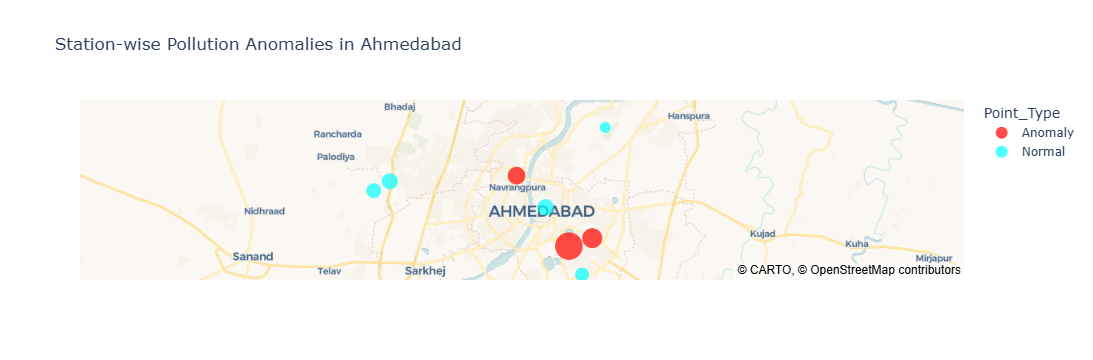

In [20]:
import pandas as pd
import plotly.express as px

# 📍 Station Coordinates
station_coords = {
    "Chandkheda": (23.1100, 72.5700),
    "Gyaspur": (22.9800, 72.6100),
    "Maninagar": (22.9980, 72.6010),
    "Raikhad": (23.0225, 72.5850),
    "Rakhial": (23.0030, 72.6170),
    "SAC ISRO Bopal": (23.0330, 72.4670),
    "SAC ISRO Satellite": (23.0390, 72.4780),
    "SVPI Airport Hansol": (23.0730, 72.6260),
    "Sardar Vallabhbhai Patel Stadium": (23.0425, 72.5650)
}

# Ensure datetime
df_model["Timestamp"] = pd.to_datetime(df_model["Timestamp"])

# Convert anomaly flag
df_model["Anomaly_Flag"] = df_model["Is_Anomaly"].astype(int)

# Map coordinates
df_model["Latitude"] = df_model["Station_Name"].map(lambda x: station_coords.get(x, (None, None))[0])
df_model["Longitude"] = df_model["Station_Name"].map(lambda x: station_coords.get(x, (None, None))[1])

# Aggregate anomalies per station
df_map = df_model.groupby(
    ["Station_Name", "Latitude", "Longitude"]
)["Anomaly_Flag"].sum().reset_index()

# 🔥 SMART THRESHOLD (based on your stats)
threshold = df_map["Anomaly_Flag"].median()   # ~64

df_map["Point_Type"] = df_map["Anomaly_Flag"].apply(
    lambda x: "Anomaly" if x > threshold else "Normal"
)

# 🌍 Create Map (UPDATED)
fig = px.scatter_map(
    df_map,
    lat="Latitude",
    lon="Longitude",
    size="Anomaly_Flag",
    color="Point_Type",
    hover_name="Station_Name",
    hover_data={"Anomaly_Flag": True},
    zoom=10,
    title="Station-wise Pollution Anomalies in Ahmedabad",
    opacity=0.7,
    color_discrete_map={
        "Normal": "cyan",
        "Anomaly": "red"
    })
fig.show()

In [19]:
print(df_map["Anomaly_Flag"].describe())

count      9.000000
mean      77.888889
std       43.071001
min       30.000000
25%       53.000000
50%       64.000000
75%       95.000000
max      177.000000
Name: Anomaly_Flag, dtype: float64


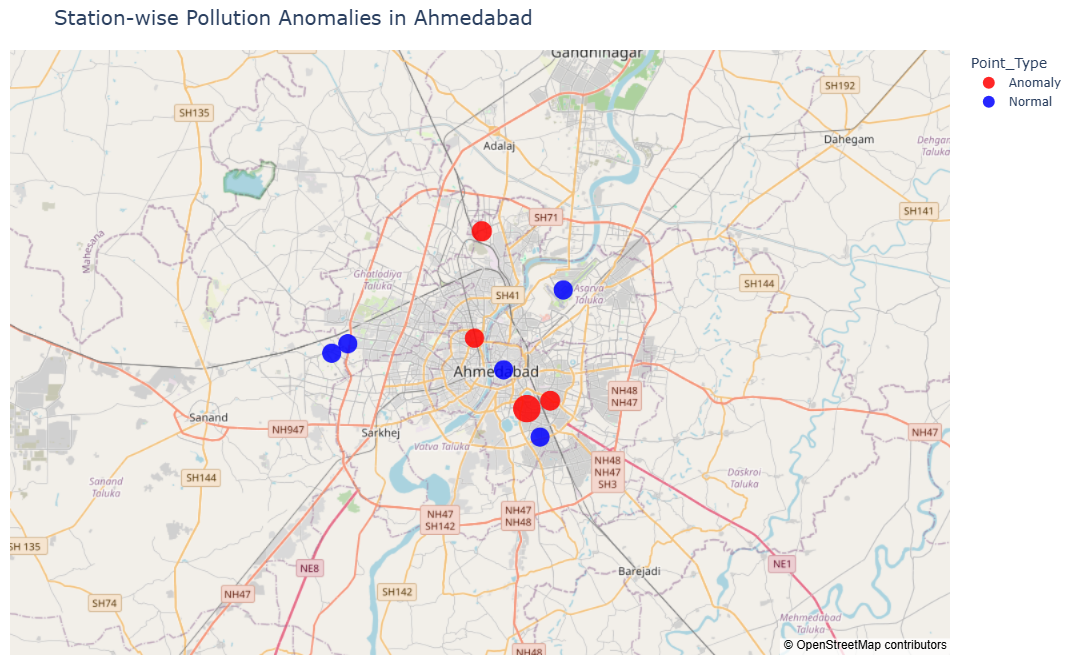

In [27]:
import pandas as pd
import plotly.express as px

# Aggregate data
df_map = df_model.groupby(
    ["Station_Name", "Latitude", "Longitude"]
)["Anomaly_Flag"].sum().reset_index()

# Smart threshold
threshold = df_map["Anomaly_Flag"].median()

df_map["Point_Type"] = df_map["Anomaly_Flag"].apply(
    lambda x: "Anomaly" if x > threshold else "Normal"
)

# 🌍 Create Map
fig = px.scatter_map(
    df_map,
    lat="Latitude",
    lon="Longitude",
    size="Anomaly_Flag",
    color="Point_Type",
    hover_name="Station_Name",
    zoom=10,
    title="Station-wise Pollution Anomalies in Ahmedabad",
    opacity=0.85,
    color_discrete_map={
        "Normal": "blue",   # Clean blue
        "Anomaly": "red"   # Professional red
    }
)

# 🔥 FIX SIZE + CLEAN LOOK
fig.update_layout(
    map_style="open-street-map",   # light theme
    height=650,                   # 🔥 increase height
    width=1100,                   # 🔥 increase width
    margin=dict(l=10, r=10, t=50, b=10),
    title_font_size=20
)

# Optional: cleaner markers
fig.update_traces(marker=dict(sizemin=10))

fig.show()

